<a href="https://colab.research.google.com/github/Ansarss/Ai_learning_experiments/blob/main/UCI_Heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install pymc arviz ucimlrepo scikit-learn pandas numpy scipy matplotlib seaborn

Import the required packages and set a random seed.

In [2]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import expit, logit

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay,
    log_loss, brier_score_loss, classification_report)

from sklearn.calibration import CalibrationDisplay
from ucimlrepo import fetch_ucirepo

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

### Step 2. Get and Prepare Data

In [3]:
heart = fetch_ucirepo(id=45)
X = heart.data.features.copy()
y_raw = heart.data.targets.copy()

print(X.shape)

print("Feature shape:", X.shape)
print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y_raw.head())

print("\nData types:")
print(X.dtypes)

print("\nMissing values:")
print(X.isna().sum())

(303, 13)
Feature shape: (303, 13)

Features:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  

Target:
   num
0    0
1    2
2    1
3    0
4    0

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

Missing values:
age         0
sex     

Review the variables in `X` and `y`.

In [4]:
y = (pd.to_numeric(y_raw['num'], errors='coerce') > 0).astype(int)

print("\nOutcome counts:")
print(y.value_counts())

print("\nOutcome proportions:")
print(y.value_counts(normalize=True))


Outcome counts:
num
0    164
1    139
Name: count, dtype: int64

Outcome proportions:
num
0    0.541254
1    0.458746
Name: proportion, dtype: float64


# Step 3. Define predictors correctly

In [5]:
continuous = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

categorical = [
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca', 'thal'
]

# Keep only the selected variables
X = X[continuous + categorical].copy()

# Make sure all values are numeric
for col in continuous + categorical:
    X[col] = pd.to_numeric(X[col], errors='coerce')

print("Missing values after numeric conversion:")
print(X.isna().sum().sort_values(ascending=False))

Missing values after numeric conversion:
ca          4
thal        2
chol        0
trestbps    0
age         0
oldpeak     0
thalach     0
sex         0
cp          0
restecg     0
fbs         0
slope       0
exang       0
dtype: int64


In [6]:
# Continuous variables:
# median imputation + standardization
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# Categorical variables:
# most-frequent imputation + one-hot encoding
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        drop='first',
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, continuous),
    ('cat', categorical_pipe, categorical)
])

# Step 4. Train/test split BEFORE fitting preprocessing

In [7]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Training rows:", X_train_df.shape[0])
print("Testing rows:", X_test_df.shape[0])

print("\nTraining outcome proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting outcome proportions:")
print(y_test.value_counts(normalize=True))

Training rows: 242
Testing rows: 61

Training outcome proportions:
num
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Testing outcome proportions:
num
0    0.540984
1    0.459016
Name: proportion, dtype: float64


In [8]:
X_train = preprocess.fit_transform(X_train_df)
X_test = preprocess.transform(X_test_df)

feature_names = preprocess.get_feature_names_out().tolist()

X_train = np.asarray(X_train, dtype=float)
X_test = np.asarray(X_test, dtype=float)

y_train = y_train.to_numpy(dtype=int)
y_test = y_test.to_numpy(dtype=int)

print("Processed training shape:", X_train.shape)
print("Processed test shape:", X_test.shape)

print("\nModel features:")
print(feature_names)

Processed training shape: (242, 20)
Processed test shape: (61, 20)

Model features:
['num__age', 'num__trestbps', 'num__chol', 'num__thalach', 'num__oldpeak', 'cat__sex_1.0', 'cat__cp_2.0', 'cat__cp_3.0', 'cat__cp_4.0', 'cat__fbs_1.0', 'cat__restecg_1.0', 'cat__restecg_2.0', 'cat__exang_1.0', 'cat__slope_2.0', 'cat__slope_3.0', 'cat__ca_1.0', 'cat__ca_2.0', 'cat__ca_3.0', 'cat__thal_6.0', 'cat__thal_7.0']


# Step 5: Translate Prior knowledge into Priors

In [9]:
# Literature-informed prior prevalence
# DISCHARGE pilot study:
# obstructive CAD prevalence = 31.7%
prior_prevalence = 0.317

# Convert prevalence probability to log-odds
intercept_prior_mean = logit(prior_prevalence)

print("Prior prevalence:", prior_prevalence)
print("Intercept prior mean (log-odds):", intercept_prior_mean)

Prior prevalence: 0.317
Intercept prior mean (log-odds): -0.7675930856935094


# Step 6: fitting the Bayesian logistic regression with MCMC

In [10]:
coords = {'feature': feature_names}

with pm.Model(coords=coords) as model:

    # Prior for the intercept based on literature prevalence
    alpha = pm.Normal(
        'alpha',
        mu=intercept_prior_mean,
        sigma=1.0
    )

    # Weakly informative priors for all predictor coefficients
    beta = pm.Normal(
        'beta',
        mu=0.0,
        sigma=1.0,
        dims='feature'
    )

    # Logistic regression equation
    log_odds = alpha + pm.math.dot(X_train, beta)

    # Convert log-odds into probabilities
    p = pm.Deterministic(
        'p_train',
        pm.math.sigmoid(log_odds)
    )

    # Bernoulli likelihood for binary disease outcome
    y_obs = pm.Bernoulli(
        'y_obs',
        p=p,
        observed=y_train
    )

    # MCMC sampling
    idata = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=2,
        target_accept=0.90,
        random_seed=RANDOM_SEED,
        return_inferencedata=True
    )

Output()

# Step 7. Check MCMC quality

In [11]:
summary = az.summary(
    idata,
    var_names=['alpha', 'beta'],
    hdi_prob=0.95,
    round_to=3
)

print(summary)

divergences = int(
    idata.sample_stats['diverging'].sum().item()
)

print("\nTotal divergences:", divergences)

                         mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
alpha                  -2.814  0.518    -3.843     -1.806      0.007    0.005   
beta[num__age]          0.003  0.215    -0.403      0.440      0.002    0.002   
beta[num__trestbps]     0.278  0.196    -0.116      0.648      0.002    0.002   
beta[num__chol]         0.164  0.194    -0.231      0.530      0.002    0.002   
beta[num__thalach]     -0.463  0.241    -0.923      0.025      0.002    0.003   
beta[num__oldpeak]      0.399  0.249    -0.074      0.896      0.002    0.003   
beta[cat__sex_1.0]      1.043  0.411     0.250      1.847      0.004    0.004   
beta[cat__cp_2.0]       0.029  0.547    -1.096      1.058      0.006    0.006   
beta[cat__cp_3.0]      -0.628  0.502    -1.639      0.316      0.006    0.005   
beta[cat__cp_4.0]       1.089  0.464     0.151      1.989      0.005    0.004   
beta[cat__fbs_1.0]     -0.050  0.475    -0.982      0.886      0.004    0.006   
beta[cat__restecg_1.0] -0.13

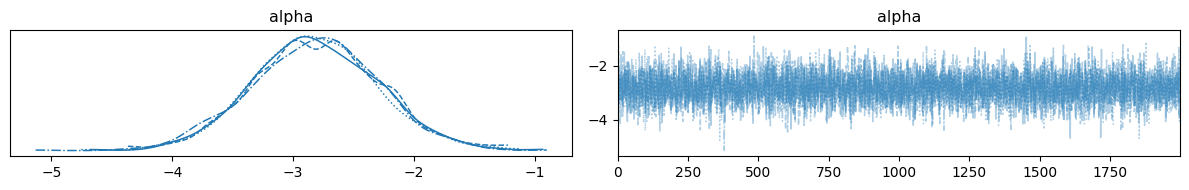

In [12]:
az.plot_trace(
    idata,
    var_names=['alpha']
)

plt.tight_layout()
plt.show()

# Step 8. Create posterior probabilities for test patients

In [13]:

alpha_draws = (
    idata.posterior['alpha']
    .stack(sample=('chain', 'draw'))
    .values
)

beta_draws = (
    idata.posterior['beta']
    .stack(sample=('chain', 'draw'))
    .transpose('sample', 'feature')
    .values
)

# Apply every posterior draw to every test patient
logits_test = alpha_draws[:, None] + beta_draws @ X_test.T

probability_draws = expit(logits_test)

# Posterior mean probability for each patient
prob_test = probability_draws.mean(axis=0)

# 95% posterior interval for each patient's predicted probability
prob_low = np.quantile(probability_draws, 0.025, axis=0)
prob_high = np.quantile(probability_draws, 0.975, axis=0)

# Classification threshold
pred_test = (prob_test >= 0.50).astype(int)

prediction_table = pd.DataFrame({
    'actual': y_test,
    'posterior_mean_probability': prob_test,
    'probability_2.5%': prob_low,
    'probability_97.5%': prob_high,
    'predicted_at_0.50': pred_test
})

print(prediction_table.head(10))

   actual  posterior_mean_probability  probability_2.5%  probability_97.5%  \
0       0                    0.244283          0.083999           0.484449   
1       0                    0.664053          0.262806           0.941182   
2       0                    0.041706          0.010797           0.104693   
3       0                    0.073508          0.015664           0.204918   
4       0                    0.358152          0.134028           0.643046   
5       0                    0.058579          0.006523           0.207153   
6       0                    0.104022          0.018688           0.302824   
7       0                    0.422176          0.105052           0.798609   
8       1                    0.694980          0.395818           0.914643   
9       0                    0.367885          0.134619           0.661060   

   predicted_at_0.50  
0                  0  
1                  1  
2                  0  
3                  0  
4                  0  
5  

# Step 9. Calculate predictive performance

In [14]:
accuracy = accuracy_score(y_test, pred_test)
auc = roc_auc_score(y_test, prob_test)
logloss = log_loss(y_test, prob_test, labels=[0, 1])
brier = brier_score_loss(y_test, prob_test)
cm = confusion_matrix(y_test, pred_test)

print("Accuracy:", accuracy)
print("ROC-AUC:", auc)
print("Log loss:", logloss)
print("Brier score:", brier)

print("\nClassification report:")
print(classification_report(y_test, pred_test, digits=3))

print("\nConfusion matrix:")
print(cm)

Accuracy: 0.8852459016393442
ROC-AUC: 0.9632034632034632
Log loss: 0.2793743305173678
Brier score: 0.08308203805741367

Classification report:
              precision    recall  f1-score   support

           0      0.906     0.879     0.892        33
           1      0.862     0.893     0.877        28

    accuracy                          0.885        61
   macro avg      0.884     0.886     0.885        61
weighted avg      0.886     0.885     0.885        61


Confusion matrix:
[[29  4]
 [ 3 25]]


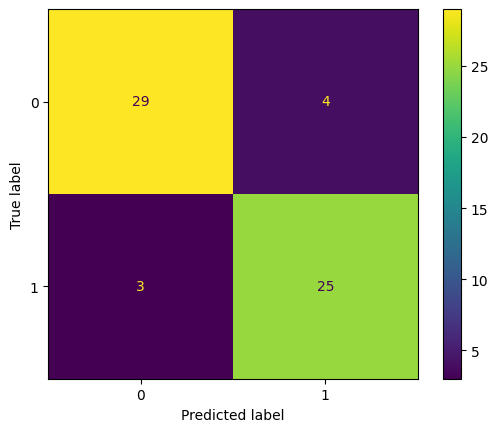

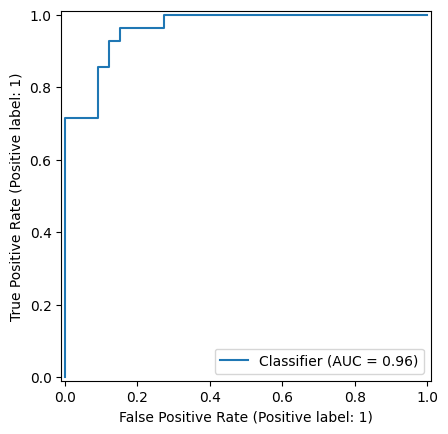

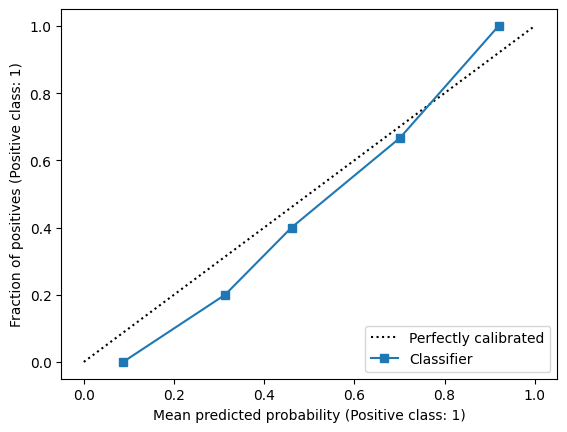

In [15]:
# Confusion matrix
ConfusionMatrixDisplay(cm).plot()
plt.show()

# ROC curve
RocCurveDisplay.from_predictions(y_test, prob_test)
plt.show()

# Calibration plot
CalibrationDisplay.from_predictions(
    y_test,
    prob_test,
    n_bins=5
)
plt.show()

# Step 10. Inspect posterior coefficients

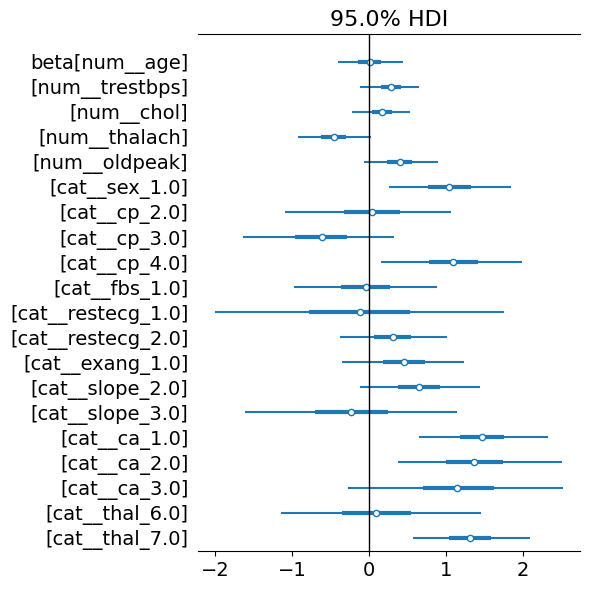

In [16]:

az.plot_forest(
    idata,
    var_names=['beta'],
    combined=True,
    hdi_prob=0.95
)

plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

In [17]:
coef_summary = az.summary(
    idata,
    var_names=['beta'],
    hdi_prob=0.95,
    round_to=3
)

coef_summary[['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%', 'r_hat', 'ess_bulk', 'ess_tail']]

,mean,sd,hdi_2.5%,hdi_97.5%,r_hat,ess_bulk,ess_tail
beta[num__age],0.003,0.215,-0.403,0.440,1.001,10698.628,6517.343
beta[num__trestbps],0.278,0.196,-0.116,0.648,1.001,11740.007,6368.381
beta[num__chol],0.164,0.194,-0.231,0.530,1.000,12889.769,5723.986
beta[num__thalach],-0.463,0.241,-0.923,0.025,1.000,11346.509,6455.051
beta[num__oldpeak],0.399,0.249,-0.074,0.896,1.001,10460.623,6879.415
beta[cat__sex_1.0],1.043,0.411,0.250,1.847,1.000,9261.434,6689.932
beta[cat__cp_2.0],0.029,0.547,-1.096,1.058,1.000,8765.332,6431.110
beta[cat__cp_3.0],-0.628,0.502,-1.639,0.316,1.000,7888.460,6726.300
beta[cat__cp_4.0],1.089,0.464,0.151,1.989,1.000,7172.570,6008.219
beta[cat__fbs_1.0],-0.050,0.475,-0.982,0.886,1.001,14486.734,6032.326


In [18]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

Sensitivity: 0.8928571428571429
Specificity: 0.8787878787878788


# Step 11. Prior-sensitivity analysis

In [19]:
prevalence_scenarios = [0.20, 0.317, 0.45]

def fit_model(prevalence):
    with pm.Model(coords={'feature': feature_names}) as m:
        a = pm.Normal(
            'alpha',
            mu=logit(prevalence),
            sigma=1.0
        )

        b = pm.Normal(
            'beta',
            mu=0.0,
            sigma=1.0,
            dims='feature'
        )

        lp = a + pm.math.dot(X_train, b)

        pm.Bernoulli(
            'y_obs',
            logit_p=lp,
            observed=y_train
        )

        fit = pm.sample(
            draws=1500,
            tune=1500,
            chains=4,
            cores=2,
            target_accept=0.90,
            random_seed=RANDOM_SEED,
            return_inferencedata=True
        )

    return fit

sensitivity_fits = {
    p: fit_model(p)
    for p in prevalence_scenarios
}

Output()

Output()

Output()

In [20]:
def evaluate_fit(fit):
    alpha_draws = (
        fit.posterior['alpha']
        .stack(sample=('chain', 'draw'))
        .values
    )

    beta_draws = (
        fit.posterior['beta']
        .stack(sample=('chain', 'draw'))
        .transpose('sample', 'feature')
        .values
    )

    logits_test = alpha_draws[:, None] + beta_draws @ X_test.T
    probability_draws = expit(logits_test)

    prob_test = probability_draws.mean(axis=0)
    pred_test = (prob_test >= 0.50).astype(int)

    return {
        'accuracy': accuracy_score(y_test, pred_test),
        'roc_auc': roc_auc_score(y_test, prob_test),
        'log_loss': log_loss(y_test, prob_test, labels=[0, 1]),
        'brier_score': brier_score_loss(y_test, prob_test)
    }

sensitivity_results = []

for prevalence, fit in sensitivity_fits.items():
    metrics = evaluate_fit(fit)

    sensitivity_results.append({
        'prior_prevalence': prevalence,
        **metrics
    })

sensitivity_table = pd.DataFrame(sensitivity_results)

print(sensitivity_table)

   prior_prevalence  accuracy   roc_auc  log_loss  brier_score
0             0.200  0.885246  0.963203  0.277970     0.082901
1             0.317  0.885246  0.964286  0.279670     0.083119
2             0.450  0.885246  0.965368  0.280096     0.083006


In [21]:
for prevalence, fit in sensitivity_fits.items():
    print(f"\nPrior prevalence: {prevalence}")

    divs = int(
        fit.sample_stats['diverging']
        .sum()
        .item()
    )

    print("Divergences:", divs)

    print(
        az.summary(
            fit,
            var_names=['alpha'],
            hdi_prob=0.95,
            round_to=3
        )
    )


Prior prevalence: 0.2
Divergences: 0
       mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
alpha -2.98  0.527    -4.007     -1.956      0.007    0.006  5285.236   

       ess_tail  r_hat  
alpha  4841.686    1.0  

Prior prevalence: 0.317
Divergences: 0
        mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
alpha -2.813  0.526    -3.809     -1.782      0.007    0.006  5430.121   

       ess_tail  r_hat  
alpha  4855.899  1.001  

Prior prevalence: 0.45
Divergences: 0
        mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
alpha -2.664  0.517     -3.66     -1.634      0.007    0.006  5236.517   

       ess_tail  r_hat  
alpha   4731.48    1.0  


# Step 12. Demonstrate sequential Bayesian updating

In [22]:
# Recreate the original training labels as a Series
y_train_series = pd.Series(
    y_train,
    index=X_train_df.index
)

X_batch1_df, X_batch2_df, y_batch1, y_batch2 = train_test_split(
    X_train_df,
    y_train_series,
    test_size=0.50,
    stratify=y_train_series,
    random_state=RANDOM_SEED
)

print("Batch 1 rows:", len(X_batch1_df))
print("Batch 2 rows:", len(X_batch2_df))

Batch 1 rows: 121
Batch 2 rows: 121


In [23]:
preprocess_update = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), continuous),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            drop='first',
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]), categorical)
])

X_batch1 = preprocess_update.fit_transform(X_batch1_df)
X_batch2 = preprocess_update.transform(X_batch2_df)
X_test_update = preprocess_update.transform(X_test_df)

update_feature_names = preprocess_update.get_feature_names_out().tolist()

X_batch1 = np.asarray(X_batch1, dtype=float)
X_batch2 = np.asarray(X_batch2, dtype=float)
X_test_update = np.asarray(X_test_update, dtype=float)

y_batch1 = np.asarray(y_batch1, dtype=int)
y_batch2 = np.asarray(y_batch2, dtype=int)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [24]:
def evaluate_update_fit(fit, X_test_eval):
    alpha_draws = (
        fit.posterior['alpha']
        .stack(sample=('chain', 'draw'))
        .values
    )

    beta_draws = (
        fit.posterior['beta']
        .stack(sample=('chain', 'draw'))
        .transpose('sample', 'feature')
        .values
    )

    logits = alpha_draws[:, None] + beta_draws @ X_test_eval.T
    probs = expit(logits)

    prob_mean = probs.mean(axis=0)
    preds = (prob_mean >= 0.50).astype(int)

    return {
        'accuracy': accuracy_score(y_test, preds),
        'roc_auc': roc_auc_score(y_test, prob_mean),
        'log_loss': log_loss(y_test, prob_mean, labels=[0, 1]),
        'brier_score': brier_score_loss(y_test, prob_mean)
    }

In [25]:
def fit_model_sequential(X_data, y_data, prior_alpha_mean, prior_beta_mu):
    with pm.Model(coords={'feature': update_feature_names}) as m_seq:
        alpha = pm.Normal(
            'alpha',
            mu=prior_alpha_mean,
            sigma=1.0
        )

        beta = pm.Normal(
            'beta',
            mu=prior_beta_mu,
            sigma=1.0,
            dims='feature'
        )

        lp = alpha + pm.math.dot(X_data, beta)

        pm.Bernoulli(
            'y_obs',
            logit_p=lp,
            observed=y_data
        )

        fit = pm.sample(
            draws=1500,
            tune=1500,
            chains=4,
            cores=2,
            target_accept=0.90,
            random_seed=RANDOM_SEED,
            return_inferencedata=True
        )
    return fit

# Initial fit for Batch 1 using the original intercept prior mean
fit_batch1 = fit_model_sequential(
    X_batch1,
    y_batch1,
    prior_alpha_mean=intercept_prior_mean,
    prior_beta_mu=0.0
)

# Extract posterior means from fit_batch1 to use as priors for Batch 2
posterior_alpha_mean_batch1 = az.summary(fit_batch1, var_names=['alpha'])['mean'].item()
posterior_beta_mean_batch1 = az.summary(fit_batch1, var_names=['beta'])['mean'].values

# Fit for Batch 2, using posteriors from Batch 1 as priors
fit_combined = fit_model_sequential(
    X_batch2,
    y_batch2,
    prior_alpha_mean=posterior_alpha_mean_batch1,
    prior_beta_mu=posterior_beta_mean_batch1
)
batch1_metrics = evaluate_update_fit(
    fit_batch1,
    X_test_update
)

combined_metrics = evaluate_update_fit(
    fit_combined,
    X_test_update
)

updating_table = pd.DataFrame([
    {'model': 'Batch 1 only', **batch1_metrics},
    {'model': 'Batch 1 + Batch 2', **combined_metrics}
])

print(updating_table)
combined_metrics = evaluate_fit(
    fit_combined,
    X_test_update
)

updating_table = pd.DataFrame([
    {'model': 'Batch 1 only', **batch1_metrics},
    {'model': 'Batch 1 + Batch 2', **combined_metrics}
])

print(updating_table)

Output()

Output()

               model  accuracy   roc_auc  log_loss  brier_score
0       Batch 1 only  0.885246  0.959957  0.316352     0.090472
1  Batch 1 + Batch 2  0.868852  0.958874  0.269675     0.085819


TypeError: evaluate_fit() takes 1 positional argument but 2 were given

In [26]:
batch1_summary = az.summary(
    fit_batch1,
    var_names=['alpha', 'beta'],
    hdi_prob=0.95
)

combined_summary = az.summary(
    fit_combined,
    var_names=['alpha', 'beta'],
    hdi_prob=0.95
)

posterior_comparison = pd.DataFrame({
    'batch1_mean': batch1_summary['mean'],
    'batch1_sd': batch1_summary['sd'],
    'combined_mean': combined_summary['mean'],
    'combined_sd': combined_summary['sd']
})

posterior_comparison['sd_change'] = (
    posterior_comparison['combined_sd']
    - posterior_comparison['batch1_sd']
)

print(posterior_comparison)

                        batch1_mean  batch1_sd  combined_mean  combined_sd  \
alpha                        -2.074      0.587         -3.240        0.655   
beta[num__age]                0.053      0.287          0.031        0.320   
beta[num__trestbps]           0.207      0.286          0.260        0.277   
beta[num__chol]               0.123      0.303          0.212        0.253   
beta[num__thalach]           -0.269      0.308         -0.981        0.401   
beta[num__oldpeak]            0.368      0.319          0.637        0.402   
beta[cat__sex_1.0]            0.443      0.525          1.593        0.593   
beta[cat__cp_2.0]            -0.558      0.741          0.207        0.634   
beta[cat__cp_3.0]            -0.422      0.592         -1.201        0.692   
beta[cat__cp_4.0]             0.838      0.566          1.201        0.590   
beta[cat__fbs_1.0]           -0.016      0.613         -0.092        0.636   
beta[cat__restecg_2.0]        0.149      0.483          0.475   